# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [336]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [337]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [338]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print(df.isnull().mean(axis = 0))

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['deck', 'embark_town', 'alone', 'who', 'adult_male', 'class', 'alive']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns = leaky)
# pd.DataFrame.drop?

print("Các cột còn lại:", list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Vì alive là cách viết khác của survived nên ta có thể thấy correlation giữa hai biến này là 1.0, nên việc sử dụng alive thì sẽ giống như một hàm ánh xạ từ alive sang survived mà không học được gì từ những feature khác.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [339]:
# TODO 2: shape, info, describe
print('Shape: ', df.shape)
print('\n\n\n',df.info())
print('\n\n\nNumeric \n',df.describe())
print('\n\n\nObject \n', df.describe(include = 'object'))

Shape:  (891, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB



 None



Numeric 
          survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000

**Trả lời 2 (biến số vs biến phân loại):**

- Target: survived
- Numeric: survived, pclass, age, sibsp, parch, fare
- Object/category: sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [340]:
# TODO 3: bảng missing (count + %)
number_nan = df.isna().sum(axis = 0) 
percent_nan = number_nan / df.shape[0] * 100

print('NaN Value \n', pd.DataFrame({'Column' : number_nan.index, 'Count' : number_nan, 'Percent NaN(%)' : percent_nan.round(2)}))



NaN Value 
             Column  Count  Percent NaN(%)
survived  survived      0            0.00
pclass      pclass      0            0.00
sex            sex      0            0.00
age            age    177           19.87
sibsp        sibsp      0            0.00
parch        parch      0            0.00
fare          fare      0            0.00
embarked  embarked      2            0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | 19.87% | Thay bằng median | age là biến numberical -> thay bằng median để ổn định hơn với outliers |
|embarked| 0.22% | Thay bằng mode hoặc bỏ luôn những hàng bị thiếu | embarked là biến category -> thay bằng mode hoặc bỏ luôn những điểm bị khuyết vì chỉ có 2 điểm dữ liệu bị khuyết|

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

age : 
 IQR : 11 , z-score : 2
fare : 
 IQR : 116 , z-score : 20


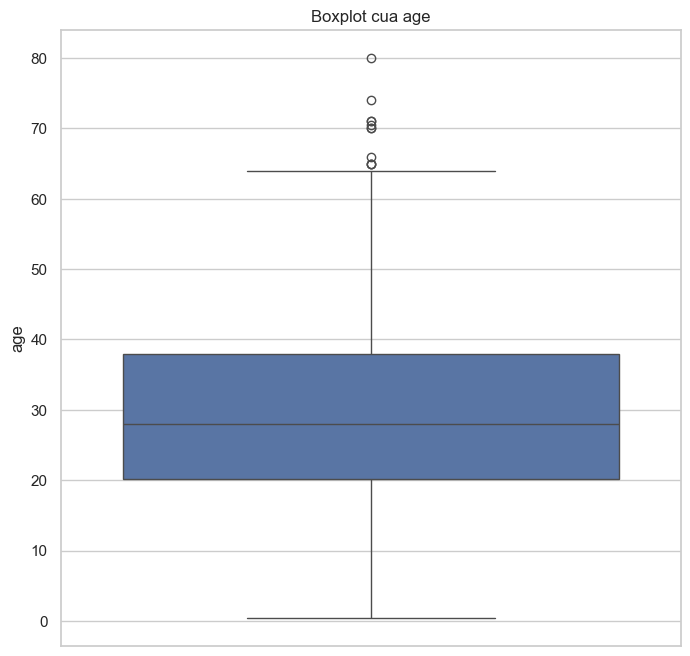

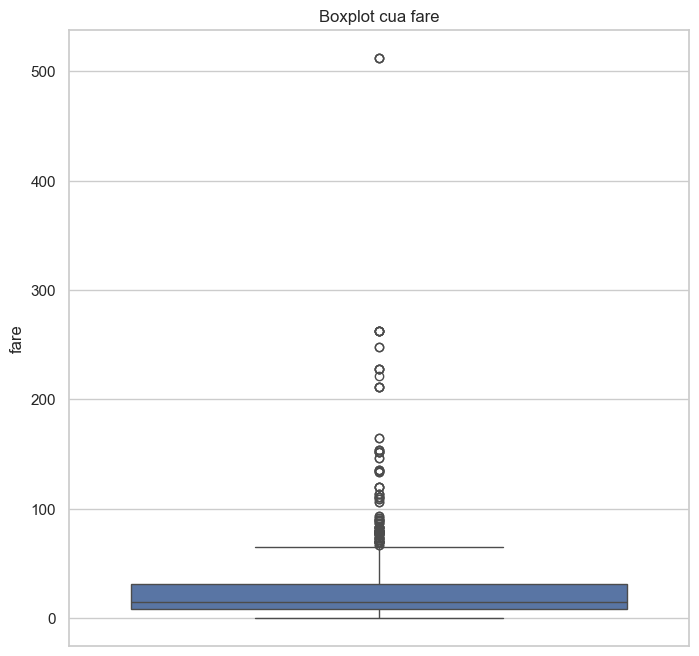

In [341]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
from scipy import stats

def dem_outlier_iqr(s):
    Q1 = df[s].quantile(0.25)
    Q3 = df[s].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[s] < Q1 - 1.5 * IQR) | (df[s] > Q3 + 1.5 * IQR))
    return outliers.sum()

def dem_outlier_zscore(s, nguong=3.0):
    outliers = np.abs(stats.zscore(df[s].dropna())) > nguong
    return outliers.sum()

for col in ["age", "fare"]:
    print(f"{col} : \n IQR : {dem_outlier_iqr(col)} , z-score : {dem_outlier_zscore(col)}")
    fig, ax = plt.subplots(figsize = (8, 8))
    sns.boxplot(df, y = col)
    plt.title(f'Boxplot cua {col}')


**Trả lời 4 (quyết định với outlier của `fare`):**

Nên giữ lại `fare` vì việc vé hạng nhất là dữ liệu thực tế. Dựa trên hạng vé có thể ảnh hưởng đến mức độ ưu tiên lên thuyền cứu sinh trong trướng hợp này

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

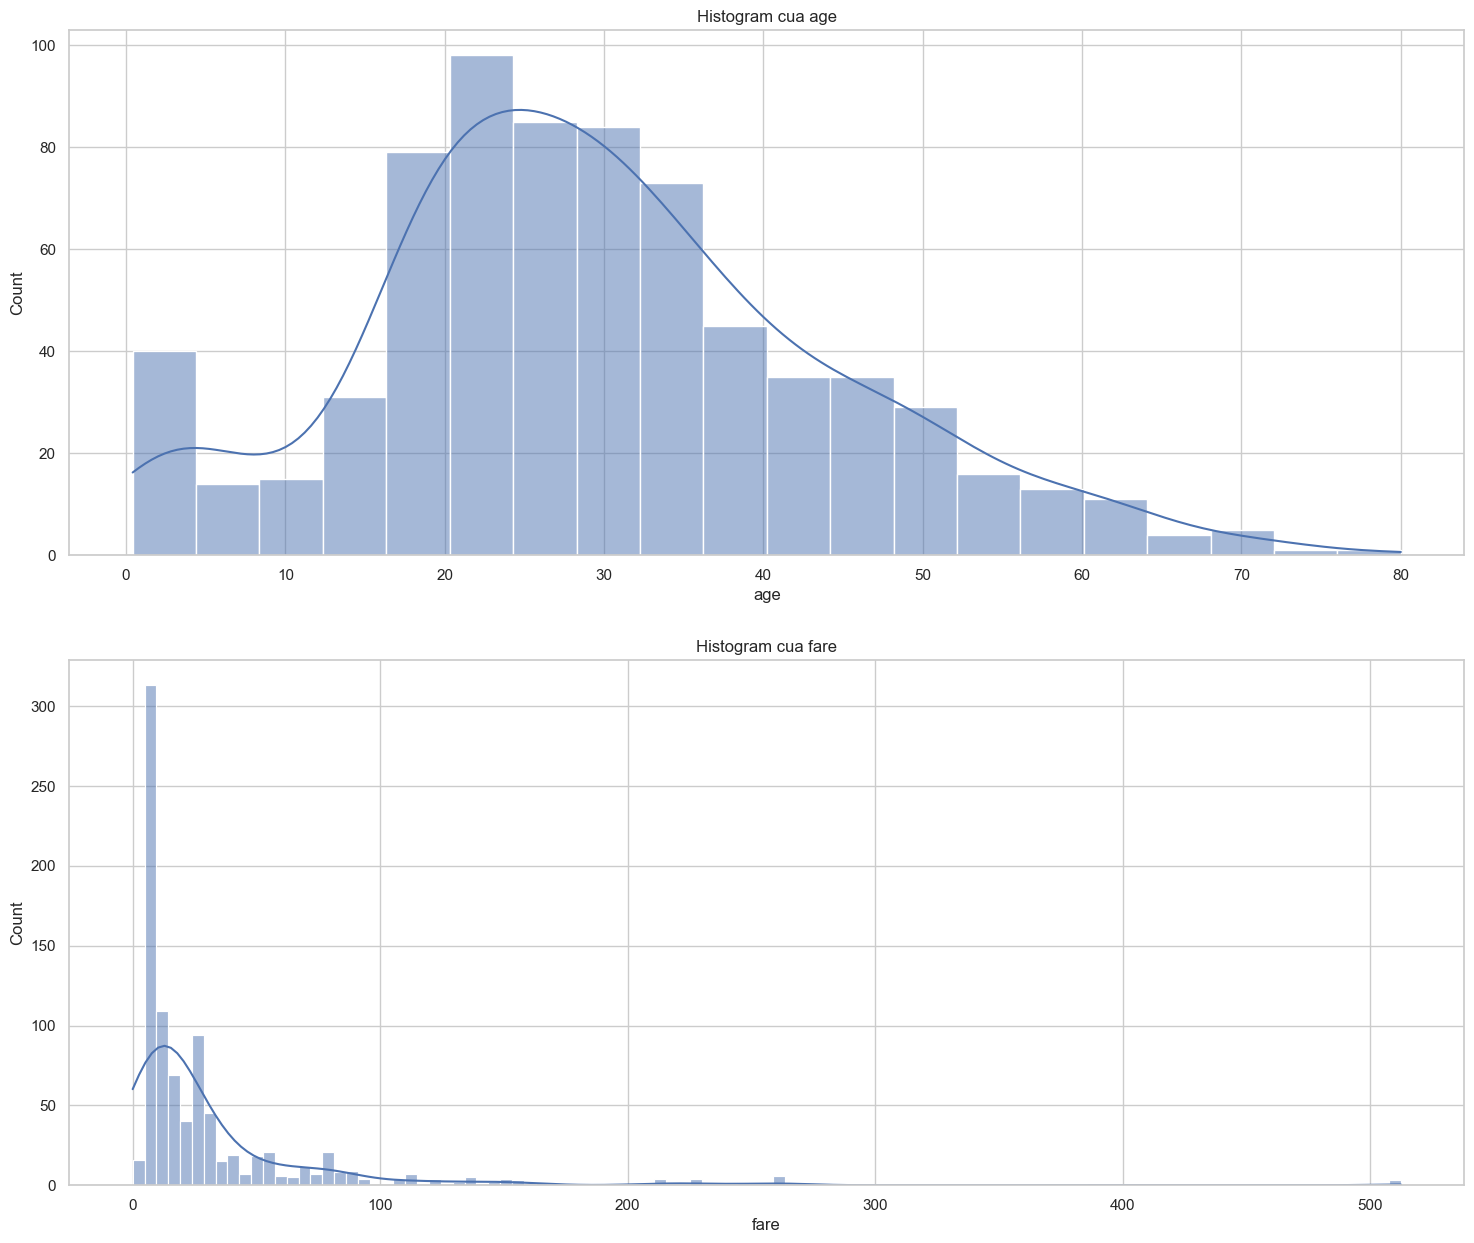

In [342]:
# TODO 5a: Histogram age & fare
fig, ax = plt.subplots(2, 1, figsize = (18, 15))
for col ,axes in zip(['age', 'fare'], ax.flat):
    sns.histplot(df, x = col, ax = axes, kde = True)
    axes.set_title(f'Histogram cua {col}')

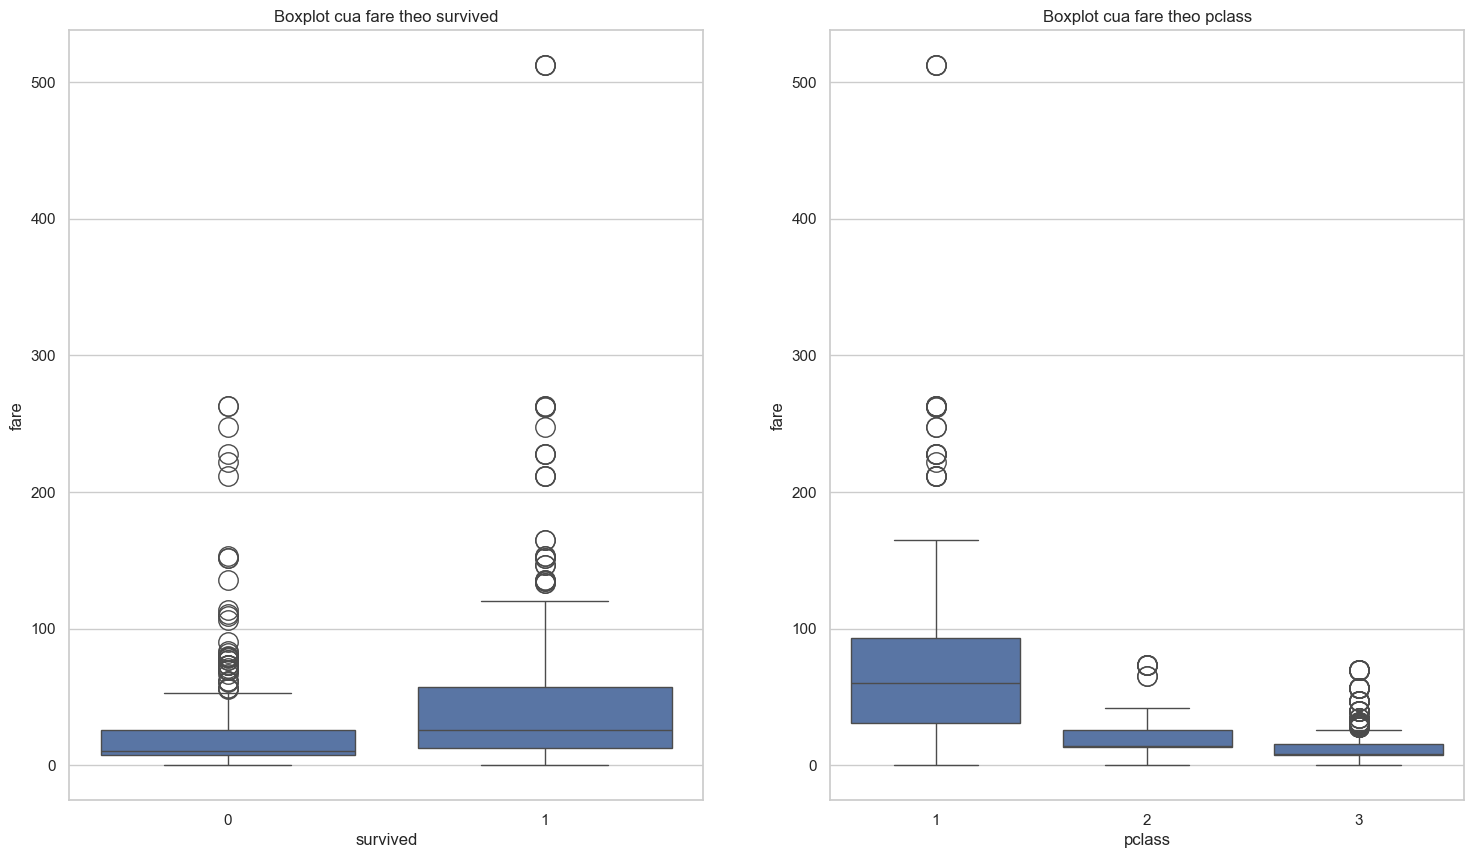

In [343]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, ax = plt.subplots(1, 2, figsize = (18, 10))
for col, axes in zip(['survived', 'pclass'], ax.flat):
    sns.boxplot(df, x = col, y = 'fare', ax = axes, fliersize = 14)
    axes.set_title(f'Boxplot cua fare theo {col}')

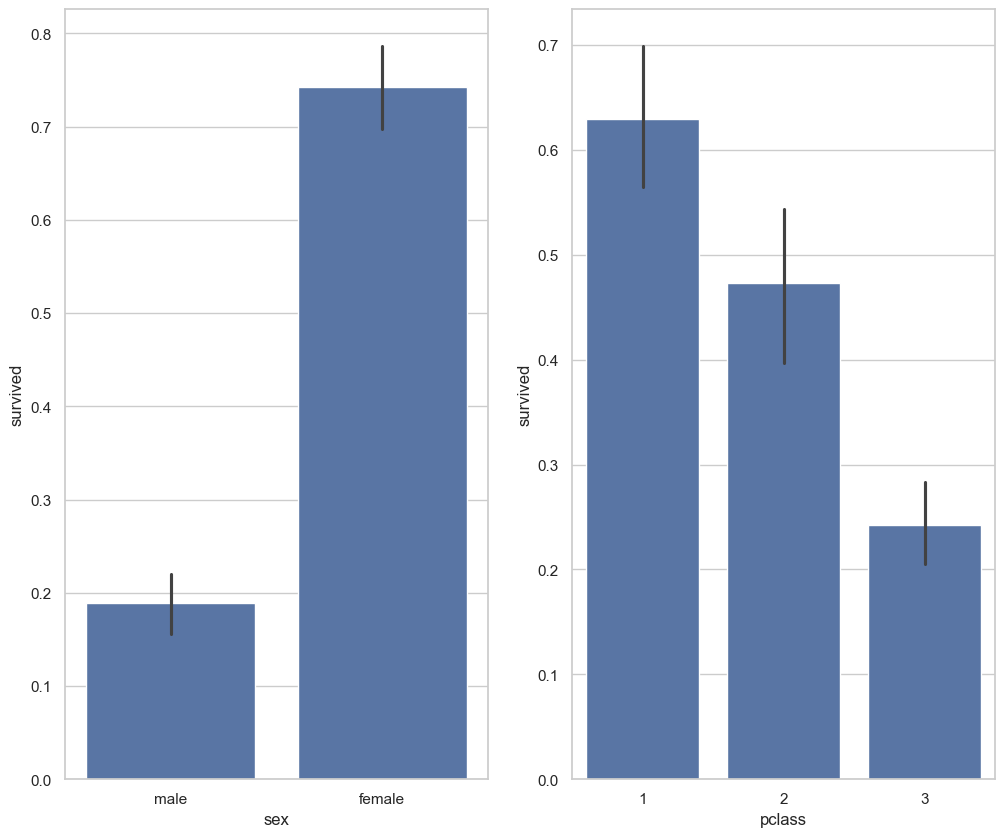

In [344]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize = (12, 10))
for col, ax in zip(['sex', 'pclass'], axes.flat):
    sns.barplot(df, x = col, y = 'survived',ax = ax)

<Axes: >

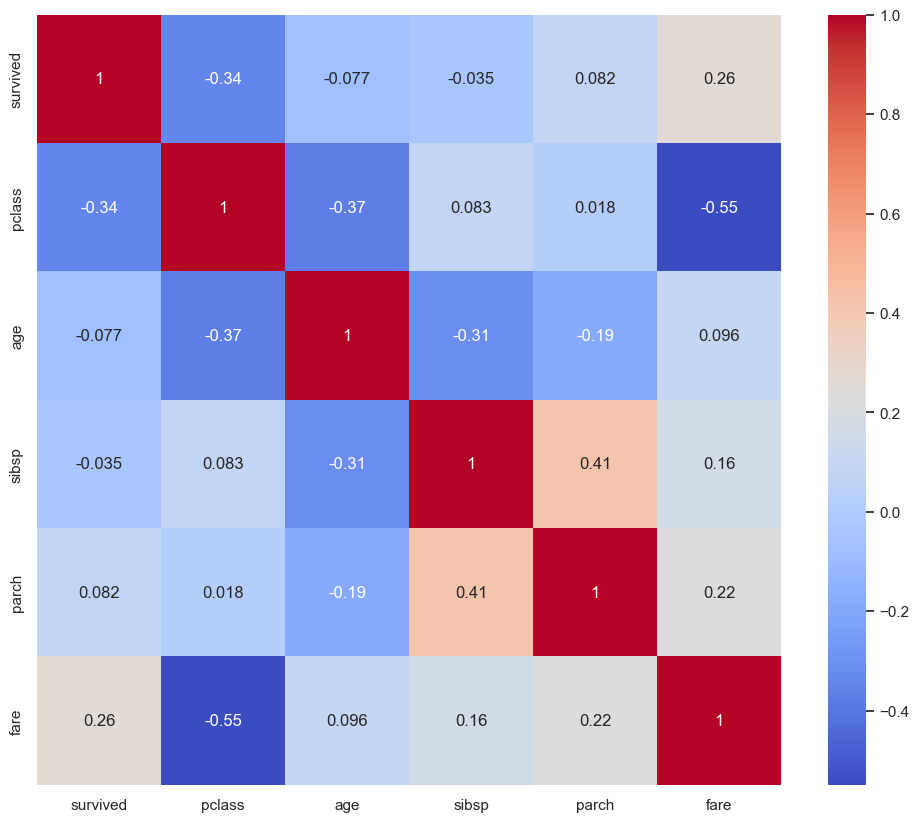

In [345]:
# TODO 5d: Heatmap correlation
df_numeric = df.select_dtypes(include = ['number'])
corr_matrix = df_numeric.corr()

fig, ax = plt.subplots(figsize = (12,10))
sns.heatmap(corr_matrix, cmap = 'coolwarm', annot = True)

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

**Histogram**

`age`:
- Biểu đồ lệch phải.
- Tập trung ở độ tuổi ~17 - ~35 tuổi và giảm dần về hai bên
- Phân đuôi bên trái có số lượng trẻ < 5 tuổi cao.


`fare`:
- Biểu đồ lệch phải mạnh.
- Giá vé tập trung chủ yếu ở giá thấp từ 0 -> khoảng 40.
- Các giá cao hơn giảm dần về phía bên phải biểu đồ vào kéo dài tới hơn 500.

**Boxplot**

`survived`
- 1: Giá trị trung vị 25 - 30. Outliers > 110 và tới hơn 500
- 0: Giá trị trung vị < 10. Ouliter > 50 và tới gần 300
-> Từ median có thể thấy hành khách mua vé giá cao hơn thì tỷ lệ sống sót cao hơn. Các outlier của 0 và 1 đều phân bổ ở những hành khách mua vé giá cao, nhưng với 1 thì các outliers này tập trung dày hơn và có các hành khách mua vé hơn 500.

`pclass`:
- 1: median khoảng 60 - 70, outliers phân bố trong khoảng từ 200 - hơn 500
- 2: median khoảng 15 - 20, outliers ít và phân bố trong khoảng từ 30 - 80
- 3: median khoảng 5, outliers phân bố nhiều và dày trong khoảng từ 30 - 80
-> Tồn tại khá nhiều các hành khác mua giá vé cao hơn cao hơn trung vị của hạng vé nhưng lại thuộc nhóm có hạng vé thấp hơn, điều này thể hiện rõ qua các outliers của `pclass = 3` và một ít ở `pclass = 2`. Outliers của pclass = 2 và 3 bé hơn 80 vậy nên việc hạng vé không tương xứng không xảy ra với các hành khách mua vé với fare > khoảng 80

**Barplot**

`sex`:
- female có tỷ lệ sống cao hơn với tỷ lệ sống sót trong khoảng 0.69 - 0.79. Trong khi đó male có tỷ lệ sống sót thấp hơn hẳn 0.16 - 0.23

`pclass`:
- Nhóm vé hạng 1 có tỷ lệ sống sót cao nhất trong khoảng từ 0.56 - 0.69. 
- Nhóm vé hạng 2 có tỷ lệ sống sót trong khoảng từ 0.39 - 0.54
- Nhóm vé hạng 3 có tỷ lệ sống sót thấp hơn hẳn hai nhóm còn lại 0.21-0.28

**Heatmap**

Các biến không tương quan mạnh với nhau nói chung. Cặp biến có độ tương quan cao hơn hẳn các cặp còn lại là 
- (`fare`, `pclass`) (-0.55): Giá vé cao thì hạng vé cao
- (`parch`, `sibsp`) (0.41): Hành khách có xu hướng đi theo gia đình
- (`age`, `pclass`) (-0.37): Tuổi càng cao thì hạng vé càng cao

Các biến tương quan rõ với `survived`:
- `fare` (0.26): giá vé cao thì khả năng sống cao. 
- `pclass` (-0.34): Hạng vé cao thì khả năng sống cao.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [346]:
# TODO 6: chia train/val/test có stratify

X = df.drop(columns = 'survived')
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size = 0.15, random_state = 42, stratify = y_tmp)

print(f'Check Shape \n Train: {X_train.shape} | Val : {X_val.shape} | Test: {X_test.shape}')
for name, label in [('train' , y_train), ('test', y_test), ('val' , y_val)]:
    print(f'Ty le song sot {name} : {label.mean():.2f}')

Check Shape 
 Train: (643, 7) | Val : (114, 7) | Test: (134, 7)
Ty le song sot train : 0.38
Ty le song sot test : 0.38
Ty le song sot val : 0.39


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [347]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]
# SimpleImputer?
# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy = 'median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy = 'most_frequent')),
    ("onehot",  OneHotEncoder(drop = 'first', handle_unknown = 'ignore')),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)   
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(643, 8) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Ví các thông số của tập dữ liệu như median/mode/... đều được mô hình học trên tập train, rồi mới áp dụng vào val và test nên mô hình sẽ không biết được thông tin từ val và test.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [348]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(f"Tỷ lệ sống sót {(y.sum() / y.shape[0] * 100):.2f}%")

Tỷ lệ sống sót 38.38%


**Trả lời 8:**

1. Biến mục tiêu survived có tỷ lệ khoảng 39:61 nên chỉ mất cân bằng nhẹ không ảnh hưởng lớn lên khả năng dự đoán của mô hình.
2. Trong trường hợp dữ liệu bị mất cân bằng mẫu cao thì accuracy sẽ bị lừa. 
    - Giả sử nếu như ta có tỷ lệ là 95:5 thì mô hình khả năng cao sẽ tính toán giá trị đầu ra là 100% -> Accuracy sẽ rất cao khoảng 95%
3. Vì dữ liệu mất cân bằng nhẹ nên trong trường hợp này ta có thể sử dụng F1-score, precision, recall và accuracy. Nhưng ta ưu tiên các metrics khác hơn accuracy

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Ta có sex có tỷ lệ tương quan mạnh với tỷ lệ sống sót (female khoảng 74% và male khoảng 19%).
2. deck khoảng 77% dữ liệu, age -> median, embarked -> mode.
3. Biến mục tiêu mất cân nhẹ 39:61 nên ta ưu tiên precision/recall/f1 hơn là accuracy
4. Các feature số cần scaling: `age`, `sibsp`, `parch`, `fare`. Các feature phân loại cần encoding: `sex`, `embarked`.
5. Trả cùng giá vé mà lại đi lên thuyền theo hai hạng khác nhau dựa trên các outlier khi biểu diễn fare theo pclass.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

impute khong scale fare 
     survived  pclass   age  sibsp  parch     fare
5        0.0     3.0  26.5    0.0    0.0   8.4583
17       1.0     2.0  32.0    0.0    0.0  13.0000
19       1.0     3.0  18.5    0.0    0.0   7.2250
26       0.0     3.0  35.0    0.0    0.0   7.2250
28       1.0     3.0  24.0    0.0    0.0   7.8792


impute khi scale fare 
         fare  survived  pclass  sibsp  parch    age
5  -0.259680       0.0     3.0    0.0    0.0  26.50
17 -0.062981       1.0     2.0    0.0    0.0  32.00
19 -0.313093       1.0     3.0    0.0    0.0  18.50
26 -0.313093       0.0     3.0    0.0    0.0  42.75
28 -0.284760       1.0     3.0    0.0    0.0  24.00
Thong so khi chưa scale fare
          survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.6

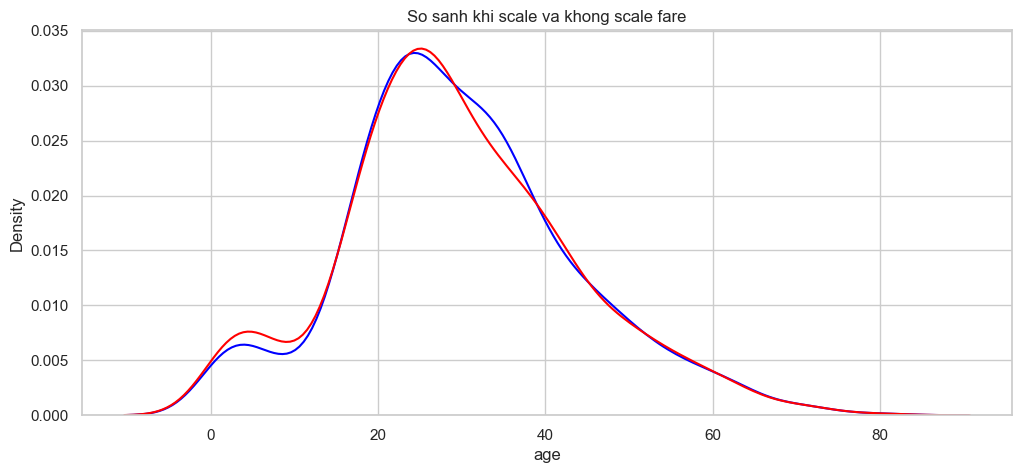

In [349]:
# (tùy chọn) code cho phần Bonus
from sklearn.impute import KNNImputer

newdf = df.drop(columns = ['sex', 'embarked'])
age_nan_index = newdf['age'].isna()

#impute age khong scale fare
pipe_age  = Pipeline([
    ("imputer", KNNImputer(n_neighbors = 2)),
])  

impute_age_no_scale = pd.DataFrame(pipe_age.fit_transform(newdf), columns=newdf.columns)
print('impute khong scale fare \n', impute_age_no_scale[age_nan_index].head())

#impute age co scale fare

pipe_fare_scale = Pipeline([
    ('scaler', RobustScaler()),
])

preprocess1 = ColumnTransformer([
    ('fare', pipe_fare_scale, ['fare']), 
    ("ord", "passthrough", ['survived',  'pclass', 'sibsp', 'parch', 'age']),
])

scaled_columns = ['fare', 'survived', 'pclass', 'sibsp', 'parch', 'age']
scale_df = pd.DataFrame(preprocess1.fit_transform(newdf), columns = scaled_columns)

impute_age_with_scale = pd.DataFrame(pipe_age.fit_transform(scale_df), columns=scale_df.columns)

print('\n\nimpute khi scale fare \n',impute_age_with_scale[age_nan_index].head())

fig, ax = plt.subplots(figsize = (12, 5))
sns.kdeplot(impute_age_no_scale, x = 'age', color = 'blue')
sns.kdeplot(impute_age_with_scale, x = 'age', color = 'red')
plt.title('So sanh khi scale va khong scale fare')


print('Thong so khi chưa scale fare\n', newdf.describe())
print('\n\nThong so khi  scale fare\n', impute_age_with_scale.describe())

Nhìn biểu đồ ta thấy được rằng hai cách impute khi không scale và scale có sự chênh lệch. Do giá trị của fare chênh lệch lớn so với các feature khác chẳng hạn như fare thuộc khoảng min/max là 0/~512 trong khi pclass là 1/3. Vậy nên việc đo bằng euclid sẽ kéo giá trị rất xa khỏi similarity thực tế.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
